# Microglia downstream analysis

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import scanpy as sc
import pybedtools
pd.options.mode.chained_assignment = None

In [2]:
root_dir = "/tscc/projects/ps-epigen/users/biy022/MGH/data/tissue/region_combined_analysis/"
os.chdir(Path(root_dir) / "scenicplus" / "all")

In [3]:
import anndata
import decoupler as dc

### Skip the next step

In [4]:
MGH_atac_counts = sc.read_mtx("MGH_atac_counts.mtx")
MGH_atac_counts = MGH_atac_counts.T.copy()
atac_cell_meta = pd.read_csv("MGH_meta_data.tsv", sep="\t", header=0, index_col=0)
atac_region_names = pd.read_csv("MGH_region_names.tsv", sep="\t", header=None, index_col=0)
atac_region_names.index.name = None
MGH_atac_counts.obs = atac_cell_meta
MGH_atac_counts.var = atac_region_names
MGH_atac_counts.write("MGH_atac_counts.h5ad")

## Preprocessing

In [4]:
MGH_rna = sc.read_h5ad("MGH_rna_counts.h5ad")
MGH_rna = MGH_rna.raw.to_adata()
MGH_rna_micro = MGH_rna[MGH_rna.obs["Subclass"] == "Micro/PVM", ]

In [5]:
MGH_micro_rna_agg = dc.get_pseudobulk(
    adata=MGH_rna_micro,
    sample_col="orig.ident",
    groups_col=None,
    min_cells=0,
    min_counts=0,
    min_prop=0.0,
    min_smpls=0,
    remove_empty=False,
    mode="sum"
)

/tscc/nfs/home/biy022/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [6]:
sc.pp.normalize_total(MGH_micro_rna_agg, target_sum=1e6)
sc.pp.log1p(MGH_micro_rna_agg, base=2)

/tscc/nfs/home/biy022/miniconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:155: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [7]:
MGH_atac = sc.read_h5ad("MGH_atac_counts.h5ad")
MGH_atac_micro = MGH_atac[MGH_atac.obs["Subclass"] == "Micro/PVM", ]

In [8]:
MGH_micro_atac_agg = dc.get_pseudobulk(
    adata=MGH_atac_micro,
    sample_col="orig.ident",
    groups_col=None,
    min_cells=0,
    min_counts=0,
    min_prop=0.0,
    min_smpls=0,
    remove_empty=False,
    mode="sum"
)

/tscc/nfs/home/biy022/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [9]:
sc.pp.normalize_total(MGH_micro_atac_agg, target_sum=1e6)
sc.pp.log1p(MGH_micro_atac_agg, base=2)

/tscc/nfs/home/biy022/miniconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:155: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


## Inspect module scores

In [10]:
MGH_regulon_module_scores = pd.read_csv(
    "MGH_regulon_module_scores.tsv", header=0, index_col=0, sep="\t")

In [11]:
MGH_regulon_module_scores_micro = MGH_regulon_module_scores.loc[MGH_rna_micro.obs.index, :]
MGH_regulon_module_scores_micro["AD"] = MGH_rna_micro.obs["AD"].copy()
MGH_regulon_module_scores_micro.reset_index(inplace=True)

In [12]:
MGH_micro_module_scores_plot = MGH_regulon_module_scores_micro.melt(id_vars=["index", "AD"])
MGH_micro_module_scores_plot.columns = ["barcode", "disease", "ereg_name", "score"]

In [13]:
num_eregs = MGH_regulon_module_scores.shape[1]
num_cols = 30
num_rows = int(np.ceil(num_eregs / num_cols))

In [14]:
MGH_micro_module_scores_plot.sort_values(
    by="ereg_name", axis=0, kind="mergesort", inplace=True)
uniq_eregs = MGH_micro_module_scores_plot["ereg_name"].unique()
ereg_index = dict()
for index, name in enumerate(uniq_eregs):
    ereg_index[name] = index
MGH_micro_module_scores_plot["ereg_index"] = MGH_micro_module_scores_plot["ereg_name"].map(ereg_index)

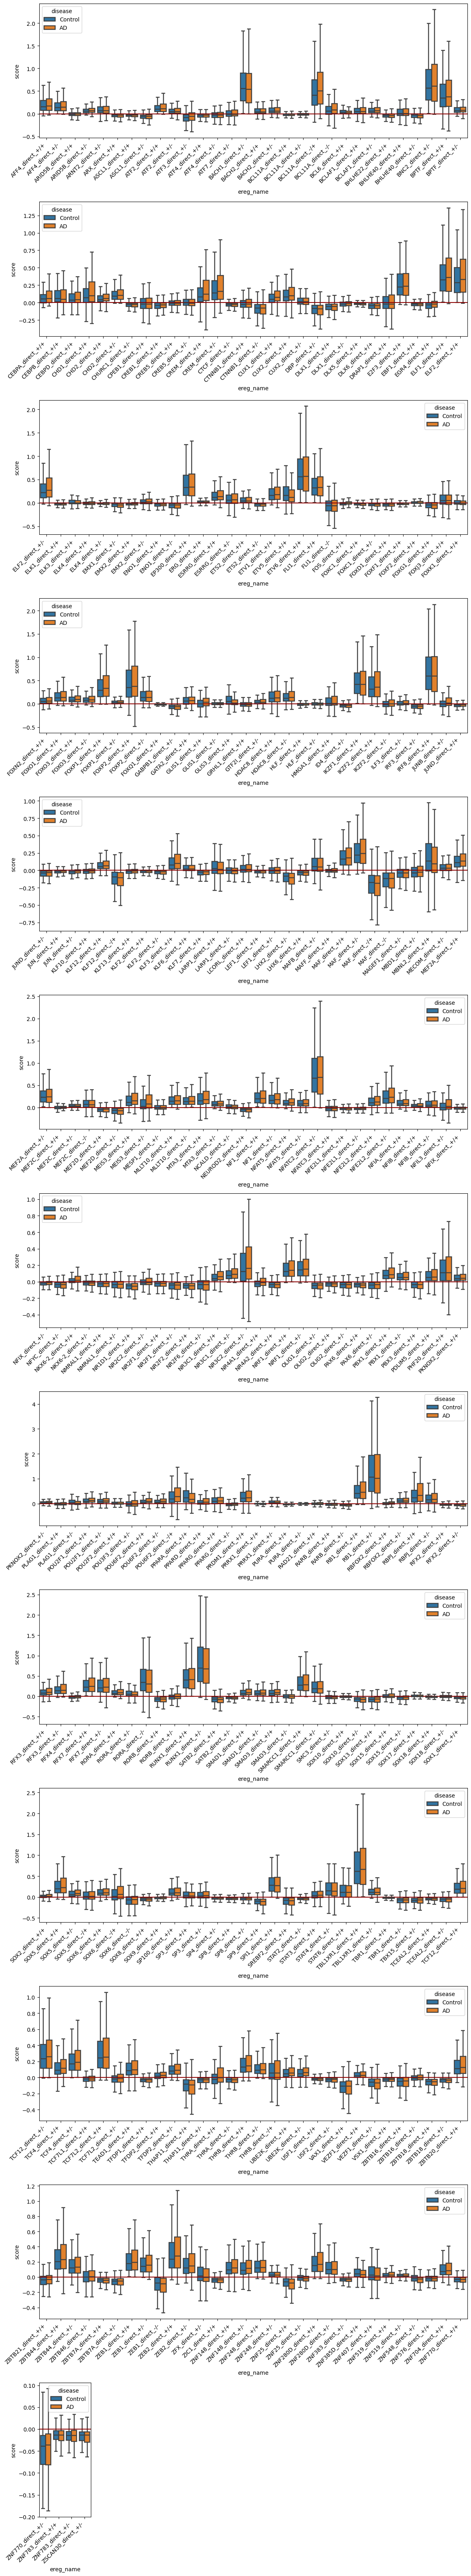

In [15]:
fig = plt.figure(constrained_layout=False)
gs = fig.add_gridspec(nrows=num_rows, ncols=num_cols)
fig.set_figheight(5 * num_rows)
fig.set_figwidth(12)

for index, start_index in enumerate(np.arange(0, num_eregs, num_cols)):
    end_index = start_index + num_cols
    plot_subdf = MGH_micro_module_scores_plot.query("ereg_index >= @start_index and ereg_index < @end_index")
    num_entries = len(plot_subdf["ereg_name"].unique())
    ax = fig.add_subplot(gs[index, 0:num_entries])
    plot_subdf["disease"] = pd.Categorical(
        plot_subdf["disease"], categories=["Control", "AD"], ordered=True)
    g = sns.boxplot(
        plot_subdf,
        x="ereg_name",
        y="score",
        hue="disease",
        showfliers=False,
        # fliersize=2.5,
        linewidth=1.75,
        ax=ax
    )
    ax.axhline(y=0.0, color="darkred")
    # ax.set_ylim([-0.5, 2.5])
    for label in g.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment("right")
plt.tight_layout()

## Intersection of cCRE with known risk variants

In [16]:
ppa_cut_variants_filename = (
    "/tscc/projects/ps-epigen/users/biy022/MGH/data/metadata/ad_risk_variants_ppa_hg38.bed")
complete_variants_filename = (
    "/tscc/projects/ps-epigen/users/biy022/MGH/data/metadata/schwartzentruber_gwas_hg38.bed")

In [17]:
ppa_cut_variants = pybedtools.BedTool(ppa_cut_variants_filename)
complete_variants = pybedtools.BedTool(complete_variants_filename)

In [18]:
direct_regulon_meta = pd.read_csv(
    "scplus_outputs/eRegulon_direct.tsv", header=0, sep="\t")

In [19]:
positive_direct_regulon_meta = direct_regulon_meta.query("regulation == 1")

In [22]:
regulon_name = "IRF8_direct_+/+"
regulon_regions = direct_regulon_meta.query(
    "eRegulon_name == @regulon_name").loc[:, ["Region", "Gene"]]
regulon_intervals = list()
for region, target_df in regulon_regions.groupby("Region"):
    chromosome, coords = region.split(":")
    start, end = coords.split("-")
    targets = ",".join(target_df["Gene"].to_list())
    regulon_intervals.append(pybedtools.Interval(
        chromosome, int(start), int(end), strand="+", name=targets))
regulon_bed = pybedtools.BedTool(regulon_intervals)
regulon_complete_variants = regulon_bed.intersect(complete_variants, u=True, wa=True)

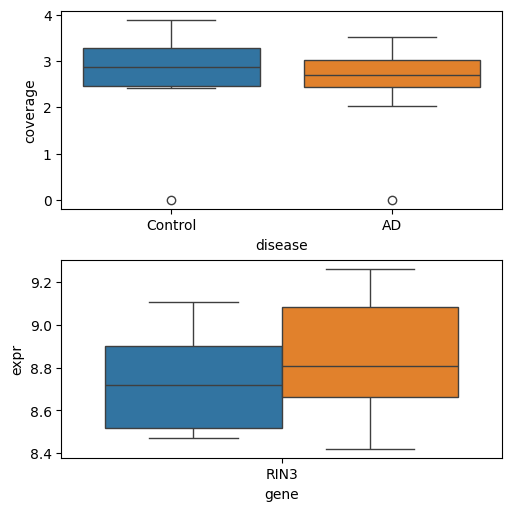

In [25]:
curr_df = regulon_complete_variants.to_dataframe()
fig = plt.figure(constrained_layout=True)
fig.set_figwidth(5)
fig.set_figheight(5)
gs = fig.add_gridspec(2, curr_df.shape[0])

for i in np.arange(0, curr_df.shape[0]):
    region_name = "{}-{}-{}".format(*curr_df.loc[i, ["chrom", "start", "end"]])
    region_df = pd.DataFrame({
        "disease": MGH_micro_atac_agg.obs["AD"].to_list().copy(),
        "coverage": MGH_micro_atac_agg[:, region_name].X.copy().flatten()
    })
    ax1 = fig.add_subplot(gs[0, i])
    sns.boxplot(data=region_df, x="disease", y="coverage", hue="disease", legend=False)

    gene_names = curr_df.loc[i, "name"].split(",")
    target_df = pd.DataFrame(MGH_micro_rna_agg[:, gene_names].X.copy(), columns=gene_names)
    target_df["disease"] = MGH_micro_rna_agg.obs["AD"].to_list().copy()
    target_df = pd.melt(target_df, id_vars="disease", var_name="gene", value_name="expr")
    ax2 = fig.add_subplot(gs[1, i])
    sns.boxplot(data=target_df, x="gene", y="expr", hue="disease", legend=False)

In [26]:
regulon_name = "SPI1_direct_+/+"
regulon_regions = direct_regulon_meta.query(
    "eRegulon_name == @regulon_name").loc[:, ["Region", "Gene"]]
regulon_intervals = list()
for region, target_df in regulon_regions.groupby("Region"):
    chromosome, coords = region.split(":")
    start, end = coords.split("-")
    targets = ",".join(target_df["Gene"].to_list())
    regulon_intervals.append(pybedtools.Interval(
        chromosome, int(start), int(end), strand="+", name=targets))
regulon_bed = pybedtools.BedTool(regulon_intervals)
regulon_complete_variants = regulon_bed.intersect(complete_variants, u=True, wa=True)

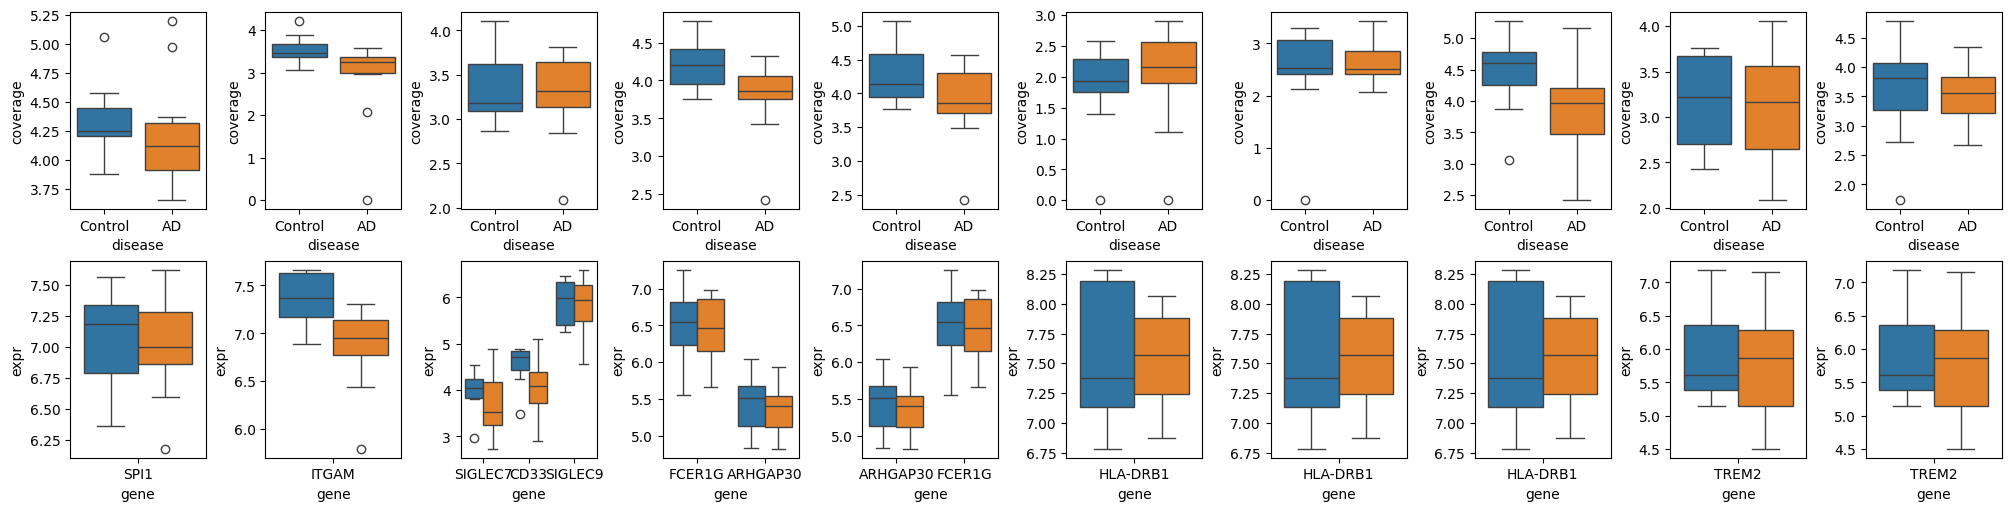

In [28]:
curr_df = regulon_complete_variants.to_dataframe()
fig = plt.figure(constrained_layout=True)
fig.set_figwidth(20)
fig.set_figheight(5)
gs = fig.add_gridspec(2, curr_df.shape[0])

for i in np.arange(0, curr_df.shape[0]):
    region_name = "{}-{}-{}".format(*curr_df.loc[i, ["chrom", "start", "end"]])
    region_df = pd.DataFrame({
        "disease": MGH_micro_atac_agg.obs["AD"].to_list().copy(),
        "coverage": MGH_micro_atac_agg[:, region_name].X.copy().flatten()
    })
    ax1 = fig.add_subplot(gs[0, i])
    sns.boxplot(data=region_df, x="disease", y="coverage", hue="disease", legend=False)

    gene_names = curr_df.loc[i, "name"].split(",")
    target_df = pd.DataFrame(MGH_micro_rna_agg[:, gene_names].X.copy(), columns=gene_names)
    target_df["disease"] = MGH_micro_rna_agg.obs["AD"].to_list().copy()
    target_df = pd.melt(target_df, id_vars="disease", var_name="gene", value_name="expr")
    ax2 = fig.add_subplot(gs[1, i])
    sns.boxplot(data=target_df, x="gene", y="expr", hue="disease", legend=False)